In [29]:
import tensorflow as tf
import pandas as pd
import numpy as np
import pickle
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
import random
import cv2
import json
warnings.filterwarnings('ignore')
from collections import defaultdict
from PIL import Image
from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory, image
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

In [94]:
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
path_to_dataset_animal = parent_path+"/Dataset/Animal_Images"
artifacts_path = current_path+"/artifacts"
animal_model_path = os.path.join(artifacts_path, "animal_model_final.keras")
animal_history_path = os.path.join(artifacts_path, "animal_history.pkl")
animal_classification_path = os.path.join(artifacts_path, "animal_class_names.json")

In [68]:
artifacts_path

'd:\\Code\\PragyaPythonProject\\ImageWebsite\\AIModel\\Model/artifacts'

In [15]:
# === Path to your ExtractedImages folder ===
extracted_root = path_to_dataset_animal

summary = []

# === Walk through each subfolder (each person) ===
for person_name in sorted(os.listdir(extracted_root)):
    person_path = os.path.join(extracted_root, person_name)
    if not os.path.isdir(person_path):
        continue  # skip any non-folder files

    # Count .png images in the folder
    image_count = len([f for f in os.listdir(person_path) if f.lower().endswith('.png')])
    summary.append((person_name, image_count))

# === Print summary ===
print(f"\n{'Animal Name':<35} | {'Image Count':>12}")
print("-" * 50)
for person, count in summary:
    print(f"{person:<35} | {count:>12}")

# === Optional total ===
total_images = sum(count for _, count in summary)
print("-" * 50)
print(f"{'TOTAL':<35} | {total_images:>12}")


Animal Name                         |  Image Count
--------------------------------------------------
antelope                            |          216
bear                                |          216
beaver                              |          216
bee                                 |          216
bison                               |          216
blackbird                           |          216
buffalo                             |          216
butterfly                           |          216
camel                               |          216
cat                                 |          432
cheetah                             |          216
chimpanzee                          |          216
chinchilla                          |          216
cow                                 |          216
crab                                |          216
crocodile                           |          216
deer                                |          216
dog                           

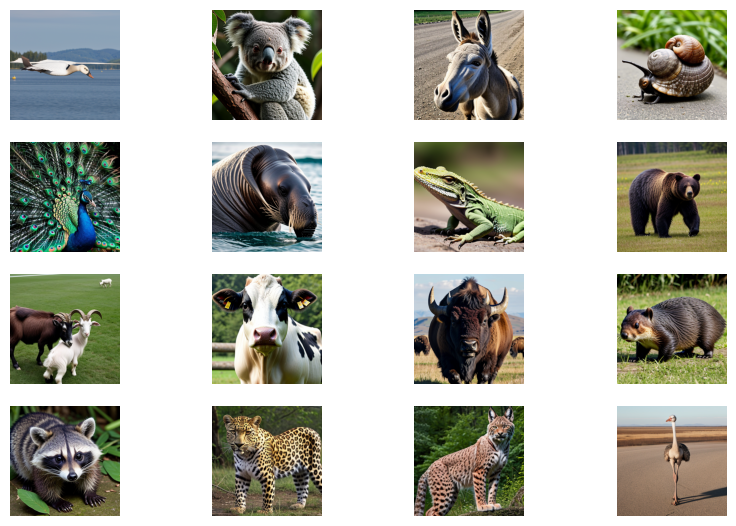

In [18]:
# === Helper function to safely sample ===
def safe_sample(items, n):
    if len(items) == 0:
        return []
    n = min(len(items), n)
    return random.sample(items, n)

# === Load Animal Images ===
animal_folder = os.listdir(path_to_dataset_animal)

# Pick 8 random animal folders (animal)
selected_animals = safe_sample(animal_folder, 16)

animal_images = []
for animals in selected_animals:
    animal_folder = os.path.join(path_to_dataset_animal, animals)
    if os.path.isdir(animal_folder):
        animal_imgs = [
            f for f in os.listdir(animal_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ]
        if animal_imgs:
            img_file = random.choice(animal_imgs)
            animal_images.append(os.path.join(animal_folder, img_file))

plt.figure(figsize=(10, 10))
for i, img_path in enumerate(animal_images):
    if i >= 24:   # prevent exceeding 6x4 grid
        break
    sp = plt.subplot(6, 4, i + 1)  # start from 1, not 0
    sp.axis('Off')

    try:
        img = mpimg.imread(img_path)
        plt.imshow(img)
    except Exception as e:
        print(f"Error loading {img_path}: {e}")


plt.show()

In [19]:
def is_tf_decodable(path):
    try:
        img_bytes = tf.io.read_file(path)
        _ = tf.image.decode_image(img_bytes)
        return True
    except:
        return False

In [20]:
for animal_folder in os.listdir(path_to_dataset_animal):
    animal_path = os.path.join(path_to_dataset_animal, animal_folder)
    if not os.path.isdir(animal_path):
        continue

    for filename in os.listdir(animal_path):
        path = os.path.join(animal_path, filename)
        if not is_tf_decodable(path):
            print("Removing bad image:", path)
            try:
                os.remove(path)
            except Exception as e:
                print(f"Error removing {path}: {e}")

In [ ]:
# === Load Animal Training and Validation Datasets ===
raw_train_ds = image_dataset_from_directory(
    path_to_dataset_animal,
    image_size=(200, 200),
    subset='training',
    seed=1,
    validation_split=0.1,
    batch_size=32
)

raw_val_ds = image_dataset_from_directory(
    path_to_dataset_animal,
    image_size=(200, 200),
    subset='validation',
    seed=1,
    validation_split=0.1,
    batch_size=32
)

# === Step 2: Get class names BEFORE prefetching ===
num_classes = len(raw_train_ds.class_names)
print("Number of classes:", num_classes)
print("Classes:", raw_train_ds.class_names)

# === Step 3: Add prefetch AFTER getting class names ===
AUTOTUNE = tf.data.AUTOTUNE
animal_train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
animal_val_ds = raw_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 14377 files belonging to 64 classes.
Using 12940 files for training.
Found 14377 files belonging to 64 classes.
Using 1437 files for validation.
Number of classes: 64
Classes: ['antelope', 'bear', 'beaver', 'bee', 'bison', 'blackbird', 'buffalo', 'butterfly', 'camel', 'cat', 'cheetah', 'chimpanzee', 'chinchilla', 'cow', 'crab', 'crocodile', 'deer', 'dog', 'dolphin', 'donkey', 'duck', 'eagle', 'elephant', 'falcon', 'ferret', 'flamingo', 'fox', 'frog', 'giraffe', 'goat', 'goose', 'gorilla', 'grasshopper', 'hawk', 'hedgehog', 'hippopotamus', 'hyena', 'iguana', 'jaguar', 'kangaroo', 'koala', 'lemur', 'leopard', 'lizard', 'lynx', 'mole', 'mongoose', 'ostrich', 'otter', 'owl', 'panda', 'peacock', 'penguin', 'porcupine', 'raccoon', 'seal', 'sheep', 'snail', 'snake', 'spider', 'squid', 'walrus', 'whale', 'wolf']


In [22]:
# === Step 4: Define CNN Model ===
animal_model = Sequential([
    layers.Rescaling(1./255, input_shape=(200, 200, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),

    # === Output Layer ===
    layers.Dense(num_classes, activation='softmax')
])

# === Step 5: Compile Model ===
animal_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

animal_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,094,528 (27.06 MB)

 Trainable params: 7,092,480 (27.06 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [23]:
# === Step 6: Train Model ===
animal_history = animal_model.fit(
    animal_train_ds,
    validation_data=animal_val_ds,
    epochs=20
)

Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - accuracy: 0.5501 - loss: 1.6941 - val_accuracy: 0.4760 - val_loss: 1.9316
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.8351 - loss: 0.5666 - val_accuracy: 0.7370 - val_loss: 1.0015
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.9165 - loss: 0.2799 - val_accuracy: 0.8518 - val_loss: 0.5644
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 444s 1s/step - accuracy: 0.9584 - loss: 0.1422 - val_accuracy: 0.8093 - val_loss: 0.6786
Epoch 5/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.9764 - loss: 0.0852 - val_accuracy: 0.8601 - val_loss: 0.5766
Epoch 6/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.9743 - loss: 0.0833 - val_accuracy: 0.6855 - val_loss: 1.6461
Epoch 7/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.9843 - loss: 0.0535 - val_accuracy: 0.8754 - val_loss: 0.4882
Epoch 8/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9790 - loss: 0.0677 - val_accu

In [86]:
# === Step 7: Save final model ===
animal_model.save(animal_model_path)
print(f"✅ Final model saved at: {animal_model_path}")

✅ Final model saved at: d:\Code\PragyaPythonProject\ImageWebsite\AIModel\Model/artifacts\animal_model_final.keras


In [87]:
with open(animal_history_path, "wb") as f:
    pickle.dump(animal_history.history, f)

In [88]:
with open(animal_classification_path, "w") as f:
    json.dump(raw_train_ds.class_names, f)

In [89]:
saved_animal_model = tf.keras.models.load_model(animal_model_path)

In [90]:
with open(animal_history_path, "rb") as f:
    saved_history_dict = pickle.load(f)

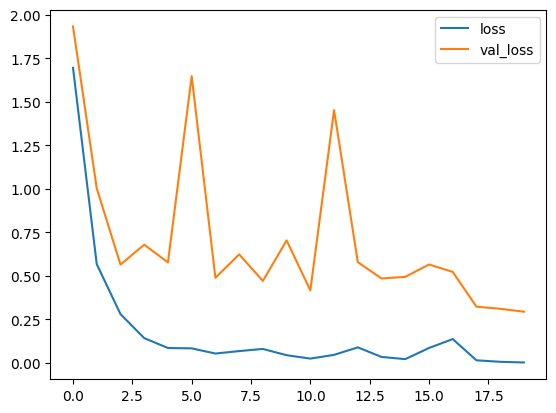

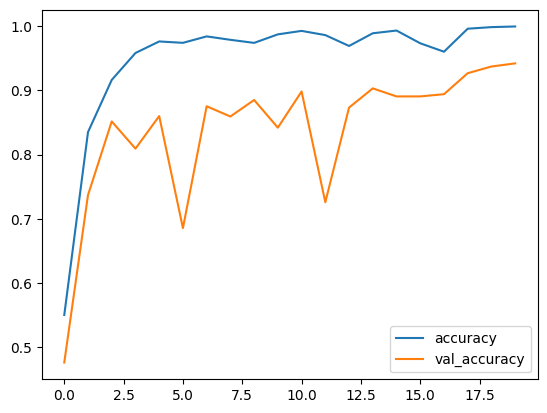

In [91]:
history_df = pd.DataFrame(saved_history_dict)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

In [48]:
import numpy as np
from keras.models import load_model
from keras.utils import load_img, img_to_array

class_names = raw_train_ds.class_names
image_path = path_to_dataset_animal + "/cat/00002-2655692277.png"   # change

# preprocess (200x200, scaled)
img = load_img(image_path, target_size=(200, 200))
x = img_to_array(img)
x = np.expand_dims(x, 0)

preds = saved_animal_model.predict(x)[0]   # shape (num_classes,)
print("argmax index:", np.argmax(preds))
print("predicted label:", class_names[np.argmax(preds)])
print("max prob:", float(np.max(preds)))
print("top 5 classes and probs:")
top5 = preds.argsort()[-5:][::-1]
for i in top5:
    print(f"  {class_names[i]:12s} -> {preds[i]:.6f}")

# Also print whole vector shape to ensure correct number of classes
print("preds shape:", preds.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
argmax index: 9
predicted label: cat
max prob: 1.0
top 5 classes and probs:
  cat          -> 1.000000
  kangaroo     -> 0.000000
  hyena        -> 0.000000
  dog          -> 0.000000
  donkey       -> 0.000000
preds shape: (64,)


In [43]:
import numpy as np

# Predict on whole validation dataset
y_true = []
y_pred = []
for images, labels in raw_val_ds:   # your dataset yields (batch_images, batch_labels)
    preds = saved_animal_model.predict(images)   # images should already be (200,200) and scaled? 
    # NOTE: raw_val_ds coming from image_dataset_from_directory does NOT auto-scale,
    # but your model has a Rescaling layer so feed raw images directly (no /255 here).
    # If you preprocessed images before creating raw_val_ds, adjust accordingly.

    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = (y_true == y_pred).mean()
print("Validation accuracy:", acc)
# Distribution of predicted classes
(unique, counts) = np.unique(y_pred, return_counts=True)
for u, c in zip(unique, counts):
    print(f"predicted class idx {u} ({class_names[u]}) -> {c} times")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
import numpy as np
from keras.models import load_model
from keras.utils import load_img, img_to_array

model = load_model("animal_model_final.keras")
class_names = raw_train_ds.class_names   # use the same class order you trained with

image_path = path_to_dataset_animal + "/cat/00002-2655692277.png"    # <-- change this

# ---- IMPORTANT: DO NOT divide by 255 here because the model has a Rescaling layer ----
img = load_img(image_path, target_size=(200, 200))
x = img_to_array(img)            # keep 0-255 values
x = np.expand_dims(x, 0)         # shape (1,200,200,3)

probs = saved_animal_model.predict(x)[0]      # probability vector
pred_idx = int(np.argmax(probs))
print("Predicted class:", class_names[pred_idx])
print("Confidence:", round(float(probs[pred_idx]), 4))

# Optional: print top-3
top3 = probs.argsort()[-3:][::-1]
print("Top-3:", [(class_names[i], round(float(probs[i]),4)) for i in top3])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted class: cat
Confidence: 1.0
Top-3: [('cat', 1.0), ('kangaroo', 0.0), ('hyena', 0.0)]


In [50]:
import numpy as np
from keras.models import load_model
from keras.utils import load_img, img_to_array

class_names = raw_train_ds.class_names   # already available in your session

# --- path to the image you want to predict ---
image_path = path_to_dataset_animal + "/buffalo/00882-1661765947.png"   # <-- change this

# --- preprocess (200x200 and scale 0-1 because your model has Rescaling layer) ---
img = load_img(image_path, target_size=(200, 200))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)   # shape (1, 200, 200, 3)

# --- predict ---
preds = saved_animal_model.predict(img_array)                # shape (1, num_classes)
pred_idx = int(np.argmax(preds[0]))
pred_confidence = float(preds[0][pred_idx])

print("Predicted class:", class_names[pred_idx])
print("Confidence:", round(pred_confidence, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted class: buffalo
Confidence: 1.0


45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step
Num samples: 1437
Num classes: 64
Overall accuracy: 0.021572720946416143


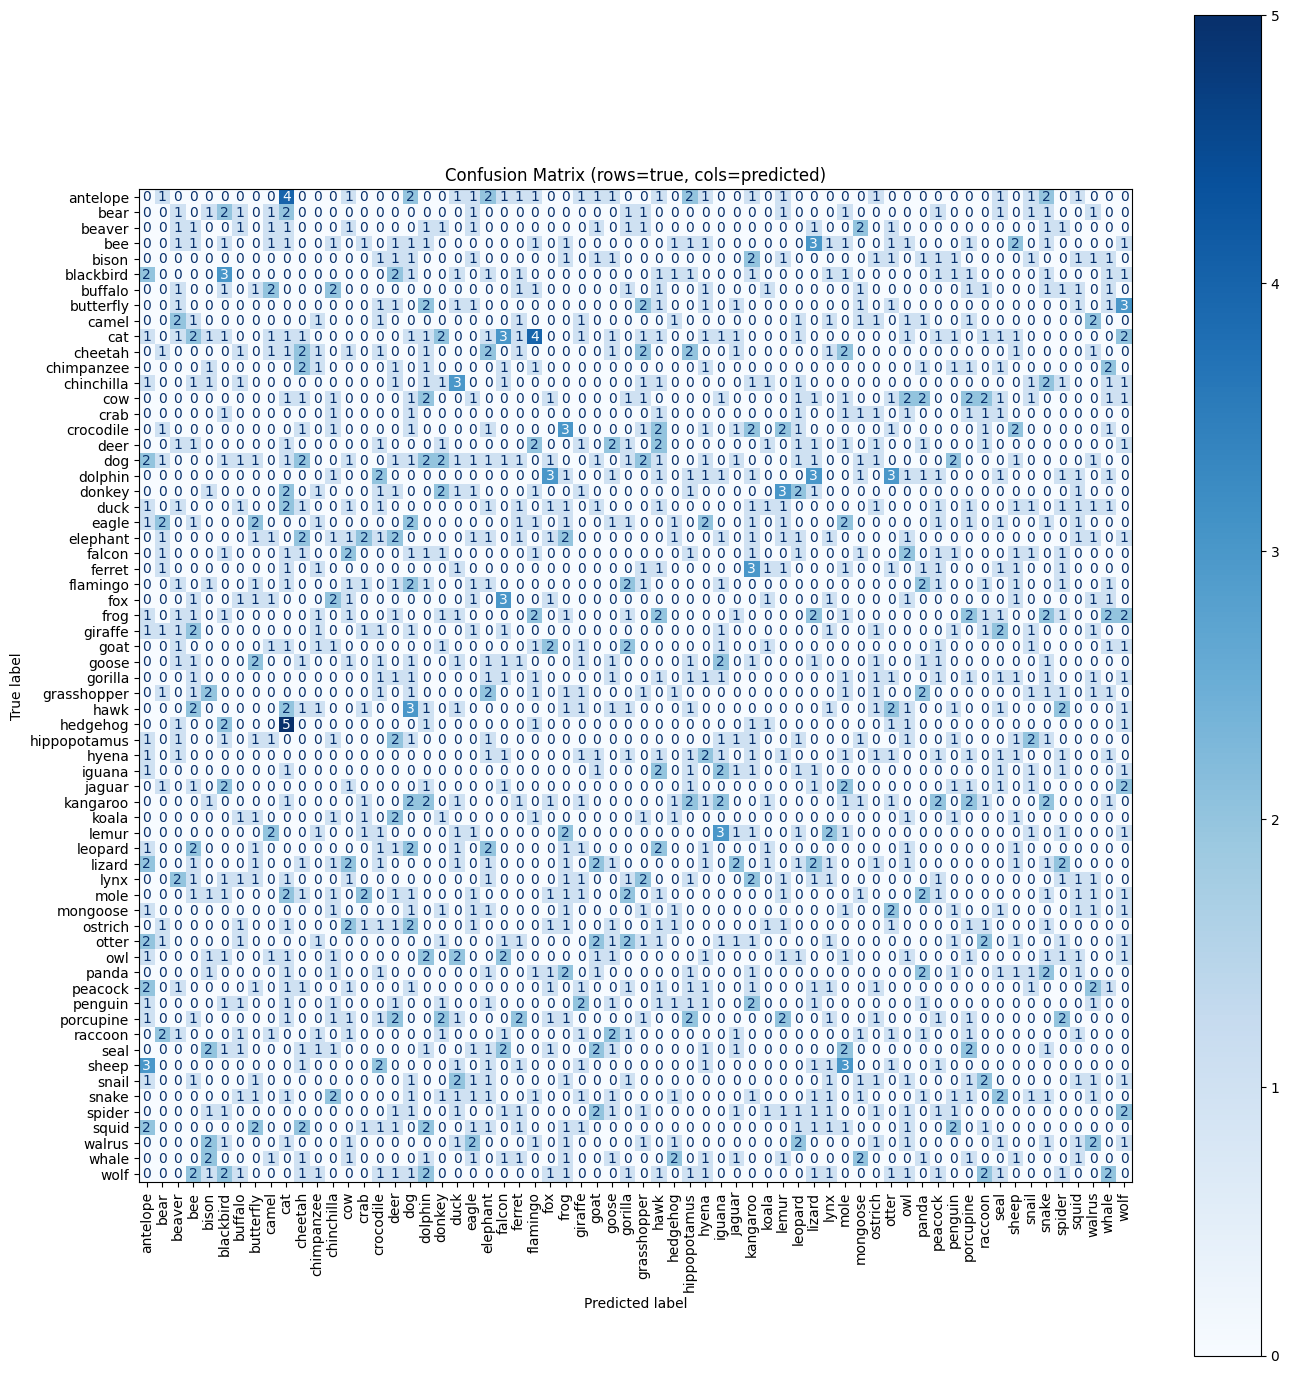

Classification Report:

              precision    recall  f1-score   support

    antelope     0.0000    0.0000    0.0000        30
        bear     0.0000    0.0000    0.0000        18
      beaver     0.0455    0.0556    0.0500        18
         bee     0.0370    0.0370    0.0370        27
       bison     0.0000    0.0000    0.0000        19
   blackbird     0.1154    0.1304    0.1224        23
     buffalo     0.0000    0.0000    0.0000        20
   butterfly     0.0000    0.0000    0.0000        19
       camel     0.0000    0.0000    0.0000        17
         cat     0.0244    0.0263    0.0253        38
     cheetah     0.0833    0.0833    0.0833        24
  chimpanzee     0.0667    0.0667    0.0667        15
  chinchilla     0.0000    0.0000    0.0000        22
         cow     0.0000    0.0000    0.0000        27
        crab     0.0000    0.0000    0.0000        12
   crocodile     0.0000    0.0000    0.0000        23
        deer     0.0000    0.0000    0.0000        21
   

In [58]:
# --- Class names from the dataset you used for training ---
class_names = raw_train_ds.class_names   # assumes raw_train_ds is present in your session
num_classes = len(class_names)

# --- 1) Get model probabilities on the full validation dataset ---
# (model includes Rescaling layer, so feed raw_val_ds directly)
y_probs = saved_animal_model.predict(raw_val_ds, verbose=1)   # shape (N, num_classes)

# --- 2) Convert probs -> predicted class indices ---
y_pred = np.argmax(y_probs, axis=1)                           # shape (N,)

# --- 3) Get true labels from raw_val_ds ---
# Use .numpy() to convert batched tensors to numpy arrays and concatenate
y_true = np.concatenate([y.numpy() for _, y in raw_val_ds], axis=0)

# --- Quick sanity checks ---
assert y_true.shape[0] == y_pred.shape[0], "Mismatch in number of predictions vs true labels"
print("Num samples:", y_true.shape[0])
print("Num classes:", num_classes)
print("Overall accuracy:", float((y_true == y_pred).mean()))

# --- 4) Confusion matrix ---
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

# Use a large figure so labels are readable for 64 classes
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical', colorbar=True)
plt.title("Confusion Matrix (rows=true, cols=predicted)")
plt.tight_layout()
plt.show()

# --- 5) Classification report (precision / recall / f1 per class) ---
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))